<a href="https://colab.research.google.com/github/mahalak2004/Machine-learning/blob/main/Decision_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Enter passenger details:
Pclass (1/2/3): 1
Sex (0=male, 1=female): 1
Age: 21
Siblings/Spouse: 1
Parents/Children: 2
Fare: 1000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(



 RESULT: PASSENGER SURVIVED 

Prediction Probability Scores:
Did Not Survive Probability : 3.12%
Survived Probability        : 96.88%


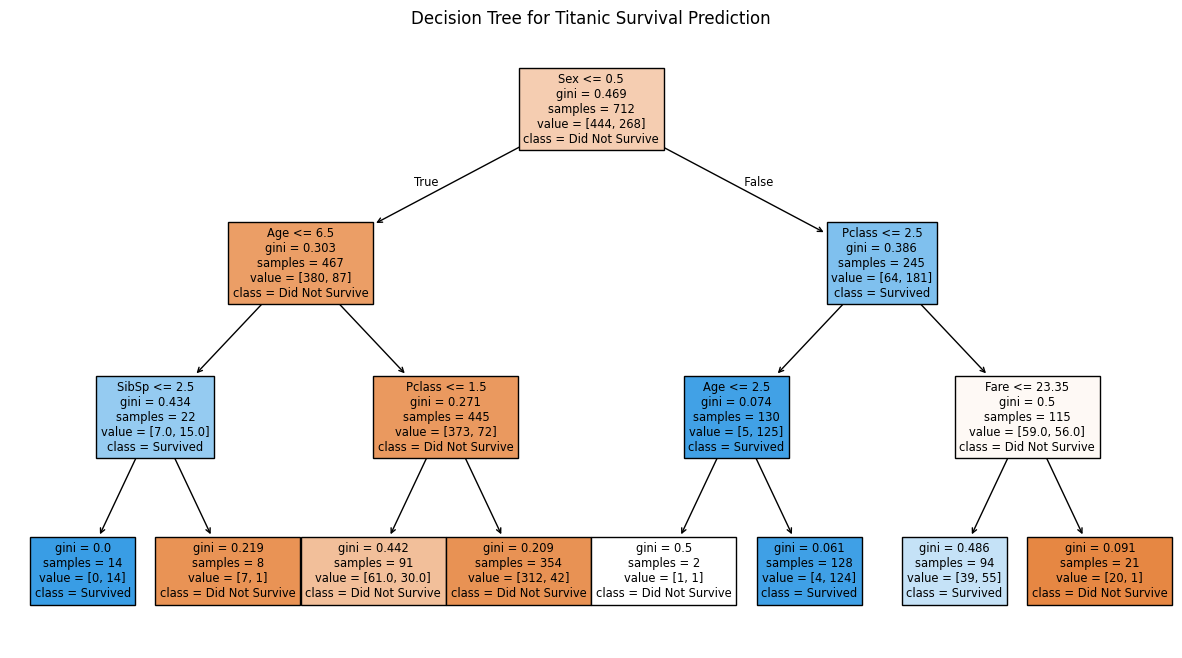

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

# -------------------------------
# Step 1: Load dataset
# -------------------------------
data = pd.read_csv("train.csv")

# -------------------------------
# Step 2: Select useful features
# -------------------------------
data = data[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']]

# -------------------------------
# Step 3: Handle missing values
# -------------------------------
data['Age'] = data['Age'].fillna(data['Age'].mean())

# Convert gender to numeric
data['Sex'] = data['Sex'].map({'male': 0, 'female': 1})

# -------------------------------
# Step 4: Split features and target
# -------------------------------
X = data.drop('Survived', axis=1)
y = data['Survived']

# -------------------------------
# Step 5: Train-test split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# Step 6: Create and train Decision Tree model
# -------------------------------
model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)

# -------------------------------
# Step 7: Take user input
# -------------------------------
print("\nEnter passenger details:")

pclass = int(input("Pclass (1/2/3): "))
sex = int(input("Sex (0=male, 1=female): "))
age = float(input("Age: "))
sibsp = int(input("Siblings/Spouse: "))
parch = int(input("Parents/Children: "))
fare = float(input("Fare: "))

new_passenger = [[pclass, sex, age, sibsp, parch, fare]]

# -------------------------------
# Step 8: Prediction + Probability
# -------------------------------
prediction = model.predict(new_passenger)
prob = model.predict_proba(new_passenger)[0]

print("\n==============================")
if prediction[0] == 1:
    print(" RESULT: PASSENGER SURVIVED ")
else:
    print(" RESULT: PASSENGER DID NOT SURVIVE ")
print("==============================")

print("\nPrediction Probability Scores:")
print(f"Did Not Survive Probability : {prob[0]*100:.2f}%")
print(f"Survived Probability        : {prob[1]*100:.2f}%")

# -------------------------------
# Step 9: Decision Tree Visualization
# -------------------------------
plt.figure(figsize=(15,8))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Did Not Survive", "Survived"],
    filled=True
)

plt.title("Decision Tree for Titanic Survival Prediction")
plt.show()